# Fast & Slow Extraction

This is a quick implementation of the Chain of Extraction + Fast & Slow thinking idea for text-to-JSON task.

## Imports

In [45]:
import json
from typing import Annotated, Any

from litellm import completion
from loguru import logger
from openai import OpenAI
from pydantic import BaseModel, Field

from agent_k.setup.load_43_101 import list_43_101_reports

# Configs
CLIENT = OpenAI()
TEMPERATURE = 0.5
MODEL = "gpt-4o-mini"
TOP_P = 0.95

## Schemas

In [46]:
class MineralSiteMetadata(BaseModel):
    mineral_site_name: str = Field(
        ..., description="The name of the mineral site that the report is about"
    )
    country: str = Field(
        ..., description="The country where the mineral site is located"
    )
    state_or_province: str = Field(
        ..., description="The state or province where the mineral site is located"
    )
    total_grade: float | str = Field(
        default="Not Found",
        description='The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be "0.35")',
    )
    total_tonnage: float | str = Field(
        default="Not Found",
        description='The total tonnage of all the nickel deposits in million tonnes (e.g. 123.4 Mt will be "123.4")',
    )
    top_1_deposit_type: str = Field(
        default="Not Found",
        description="The most likely deposit type of the mineral site",
    )
    top_1_deposit_environment: str = Field(
        default="Not Found",
        description="The most likely deposit environment of the mineral site",
    )


schema = MineralSiteMetadata.model_json_schema()
print(json.dumps(schema, indent=4))

{
    "properties": {
        "mineral_site_name": {
            "description": "The name of the mineral site that the report is about",
            "title": "Mineral Site Name",
            "type": "string"
        },
        "country": {
            "description": "The country where the mineral site is located",
            "title": "Country",
            "type": "string"
        },
        "state_or_province": {
            "description": "The state or province where the mineral site is located",
            "title": "State Or Province",
            "type": "string"
        },
        "total_grade": {
            "anyOf": [
                {
                    "type": "number"
                },
                {
                    "type": "string"
                }
            ],
            "default": "Not Found",
            "description": "The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be \"0.35\")",
            "title": "Total Grade"
        

In [47]:
class Example1(BaseModel):
    name: str
    address: str
    total_attendees: int
    oldest_attendee: str


class Example2(BaseModel):
    product_name: str
    product_type: str
    price: float
    discount: float


class Example3(BaseModel):
    address: str
    province: str
    country: str
    total_sales: float


schema_example1 = json.dumps(Example1.model_json_schema())
schema_example2 = json.dumps(Example2.model_json_schema())
schema_example3 = json.dumps(Example3.model_json_schema())
# replace "{" with "{{" and "}" with "}}" to be used in the multi-line prompt
schema_example1 = schema_example1.replace("{", "{{").replace("}", "}}")
schema_example2 = schema_example2.replace("{", "{{").replace("}", "}}")
schema_example3 = schema_example3.replace("{", "{{").replace("}", "}}")
print(schema_example1)
print(schema_example2)
print(schema_example3)

{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example1", "type": "object"}}
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "provin

## Prompts

In [48]:
SCHEMA_DECOMPOSE_SYS_PROMPT = """You are a helpful agent that groups entities in a JSON schema into two categories:
1. Simple entities in the JSON schema that can be extracted directly from the text.
2. Complex entities in the JSON schema that require reasoning or additional information to be extracted. Complex entities may include composite entities that need further decomposition or non-composite entities that require extra context for extraction.

You should enclose your reasoning within <thinking> XML tags and output the result within <output> XML tags."""

DECOMPOSE_USER_PROMPT_TEMPLATE = """# Example 1
Given the following JSON schema:
```
{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example", "type": "object"}}
```
Output:
<thinking>
"name" and "address" are not complex entities and can be extracted directly from the text. "total_attendees" is likely a complex entity because it requires extracting individual attendees and counting them. Oldest attendee is a complex entity because it requires extracting the oldest attendee from the list of attendees.
</thinking>
<output>
1. Simple entities: ["name", "address"]
2. Complex entities: ["total_attendees", "oldest_attendee"]
</output>

# Example 2
Given the following JSOn schema:
```
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
```
Output:
<thinking>
"product_name", "product_type", "price", and "discount" are all not complex entities and can be extracted directly from the text. "discount" is likely a complex entity because it requires extracting the discounted price and the original price from the text and then calculating the discount.
</thinking>
<output>
1. Simple entities: ["product_name", "product_type", "price"]
2. Complex entities: ["discount"]
</output>

# Example 3
Given the following JSON schema:
```
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "province", "country", "total_sales"], "title": "Example3", "type": "object"}}
```
Output:
<thinking>
"address", "province", and "country" are not complex entities and can be extracted directly from the text. "total_sales" is a complex entity because it requires extracting separate sale entities and then summing the sale values.
</thinking>
<output>
1. Simple entities: ["address", "province", "country"]
2. Complex entities: ["total_sales"]
</output>

# Example 4
Given the following JSON schema:
```
{json_schema}
```
Output:
"""


# Batch Extraction
PDF_AGENT_SYSTEM_PROMPT = """You are a helpful agent that extracts information from mineral PDF reports. First, identify the main mineral site name the attached NI 43-101 report is about. Then, extract the relevant entities about the mineral site based on the JSON schema provided. Finally, structure your response as a JSON object that complies with the JSON schema provided.

Output Format Instructions: You should enclose your retrieved information within <retrieved> XML tags, your reasoning within <thinking> XML tags, and your final response as a JSON object that complies with the JSON schema provided within <json> XML tags."""

PDF_AGENT_USER_PROMPT = """JSON schema provided: {json_schema}

Not take a deep breath and think step by step."""

# Deep Extraction
DEEP_EXTRACT_SYSTEM_PROMPT = """You are a helpful agent that answer questions about the attached 43-101 mineral report by retrieving relevant information from the report using the file search tool. If applicable, use the code interpreter tool to perform aggregation calculations such as summing or averaging.

Output Format Instructions: You should enclose your retrieved information within <retrieved> XML tags, your reasoning within <thinking> XML tags, and your final response within <output> XML tags."""

DEEP_EXTRACT_USER_PROMPT = """Question: What's the {field} of the mineral site in the attached 43-101 report?
{field} description: {description}
{field} data type: {dtype}
{field} default value: {default}

Please enclose your reasoning within <thinking> XML tags and output the result within <output> XML tags. Please only include the final result in <output> XML tags and nothing else.

Now take a deep breath and think step by step."""


CORRECT_EXTRACT_SYSTEM_PROMPT = """You are a helpful agent that corrects extracted information from the attached 43-101 mineral report based on the feedback and the previous extraction messages.

Reflect on the feedback, identify the potential mistakes in the previous extraction messages, and correct them. If the previous retrieved information is irrelevant, you should retrieve more information from the attached PDF.

Output Format Instructions: You should enclose your reasoning within <thinking> XML tags, and your final corrected JSON object response within <json> XML tags."""

CORRECT_EXTRACT_USER_PROMPT = """Please correct the following extraction results based on the feedback and previous extraction messages.
Extraction results: {extraction_results}
Feedback: {feedback}
Previous extraction messages: {messages}
The JSON schema is: {json_schema}
Please enclose your reasoning within <thinking> XML tags and output the result within <json> XML tags."""

VALIDATOR_SYSTEM_PROMPT = """"You are a helpful agent that validates the extraction result against the JSON schema based on the previous extraction messages. Please provide your feedback on the correctness of the extraction enclosed within <feedback> XML tags. Finally, output the result within <output> XML tags. If the extraction result is incorrect, output "NO" in the <output> XML tags. Otherwise, output "YES" in the <output> XML tags."""

VALIDATOR_USER_PROMPT = """Please validate the following extraction result based on the previous extraction messages.
Extraction result: {extraction_results}
Previous extraction messages: {messages}
The JSON schema is: {json_schema}
Please enclose your reasoning within <thinking> XML tags, feedback in <feedback> XML tags, and output the result within <output> XML tags."""

## Helper Functions

### Split JSON Schema

In [49]:
def split_json_schema(schema: dict, field_lists: list[list[str]]) -> list[dict]:
    """
    Splits a JSON schema into multiple schemas based on provided field lists.

    Args:
        schema (dict): The input JSON schema.
        field_lists (list of list of str): Each inner list contains fields for a separate schema.

    Returns:
        list of dict: A list of JSON schemas corresponding to each field list.
    """
    # Extract properties and required fields from the original schema
    original_properties = schema.get("properties", {})
    original_required = set(schema.get("required", []))

    schemas = []
    for field_list in field_lists:
        new_schema = {"type": "object", "properties": {}, "required": []}
        # Extract properties and required fields based on the field list
        for field in field_list:
            if field in original_properties:
                new_schema["properties"][field] = original_properties[field]
            if field in original_required:
                new_schema["required"].append(field)

        # Remove 'required' if empty
        if not new_schema["required"]:
            new_schema.pop("required")

        schemas.append(new_schema)

    return schemas


field_lists = [
    ["mineral_site_name", "state_or_province", "country"],
    ["total_grade", "total_tonnage"],
    ["top_1_deposit_type", "top_1_deposit_environment"],
]
result = split_json_schema(schema, field_lists)
for i, res in enumerate(result):
    print(f"Schema {i+1}:", res)

Schema 1: {'type': 'object', 'properties': {'mineral_site_name': {'description': 'The name of the mineral site that the report is about', 'title': 'Mineral Site Name', 'type': 'string'}, 'state_or_province': {'description': 'The state or province where the mineral site is located', 'title': 'State Or Province', 'type': 'string'}, 'country': {'description': 'The country where the mineral site is located', 'title': 'Country', 'type': 'string'}}, 'required': ['mineral_site_name', 'state_or_province', 'country']}
Schema 2: {'type': 'object', 'properties': {'total_grade': {'anyOf': [{'type': 'number'}, {'type': 'string'}], 'default': 'Not Found', 'description': 'The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be "0.35")', 'title': 'Total Grade'}, 'total_tonnage': {'anyOf': [{'type': 'number'}, {'type': 'string'}], 'default': 'Not Found', 'description': 'The total tonnage of all the nickel deposits in million tonnes (e.g. 123.4 Mt will be "123.4")', 'title': 

### Parse JSON Code Block

In [50]:
def parse_json_code_block(content: str) -> dict[str, Any]:
    """Parse the JSON code block from the assistant response."""
    try:
        json_code_block = content.split("<json>")[1].split("</json>")[0]
        return json.loads(json_code_block)
    except Exception as e:
        logger.error(f"Failed to parse JSON code block: {e}")
        logger.error(f"LLM response: {content}")
        return {}

### Prompt OpenAI Assistant

In [51]:
from openai.types.beta import Assistant


def prompt_openai_assistant(assistant: Assistant, messages: list[dict]) -> str:
    thread = CLIENT.beta.threads.create(messages=messages)

    # Use the create and poll SDK helper to create a run and poll the status of
    # the run until it's in a terminal state.
    run = CLIENT.beta.threads.runs.create_and_poll(
        thread_id=thread.id,
        assistant_id=assistant.id,
    )
    messages = list(
        CLIENT.beta.threads.messages.list(thread_id=thread.id, run_id=run.id)
    )
    message_content = messages[0].content[0].text
    annotations = message_content.annotations
    citations = []
    for index, annotation in enumerate(annotations):
        message_content.value = message_content.value.replace(
            annotation.text, f"[{index}]"
        )
        if file_citation := getattr(annotation, "file_citation", None):
            cited_file = CLIENT.files.retrieve(file_citation.file_id)
            citations.append(f"[{index}] {cited_file.filename}")

    logger.debug(message_content.value)
    logger.debug("\n".join(citations))

    return message_content.value

### Extract from PDF

In [52]:
def batch_extract(
    pdf_path: str,
    json_schema: dict,
) -> str:
    """
    Extract entities from a PDF file using OpenAI Assistant.
    """

    logger.info("Batch extracting entities from the 43-101 report")
    json_schema_str = json.dumps(json_schema)

    assistant = CLIENT.beta.assistants.retrieve("asst_dbMIxMYwSocPIKpZ3KLnadWB")

    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    messages = [
        {
            "role": "user",
            "content": PDF_AGENT_USER_PROMPT.format(
                json_schema=json_schema_str,
            ),
            "attachments": [
                {
                    "file_id": file_id,
                    "tools": [
                        {"type": "file_search"},
                        {"type": "code_interpreter"},
                    ],
                }
            ],
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content


def deep_extract(pdf_path: str, field, default, description, dtype):
    """
    Extract ONE entity from a PDF file using OpenAI Assistant.
    """
    logger.info(f"Extracting {field} from {pdf_path}")
    assistant = CLIENT.beta.assistants.retrieve("asst_50sbd2mNoNhaPecIKU34vXUP")

    # Get the OpenAI file ID
    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    messages = [
        {
            "role": "user",
            "content": DEEP_EXTRACT_USER_PROMPT.format(
                field=field,
                description=description,
                dtype=dtype,
                default=default,
            ),
            "attachments": [
                {
                    "file_id": file_id,
                    "tools": [
                        {"type": "file_search"},
                        {"type": "code_interpreter"},
                    ],
                }
            ],
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content

# LangGraphs
## States and Routes

In [53]:
from ast import literal_eval
from typing import Literal

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import TypedDict


def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    pdf_path: str  # 43-101 report record ID
    json_schema: dict  # Predefined JSON schema (Assumed it's available)
    method: Literal["DPE", "F&S"]

    # Populated by LLMs
    simple_entities: list[str]
    complex_entities: list[str]
    fast_extraction_agent_result: dict[str, Any]
    slow_extraction_agent_result: dict[str, Any]
    slow_extraction_validated: Literal["YES", "NO"]
    feedback: Annotated[list, add_messages]
    messages: Annotated[list, add_messages]
    final_extraction_result: dict


def schema_decompose(state: State):
    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": SCHEMA_DECOMPOSE_SYS_PROMPT},
            {
                "role": "user",
                "content": DECOMPOSE_USER_PROMPT_TEMPLATE.format(
                    json_schema=json.dumps(state["json_schema"])
                ),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )

    # Parse the <output> XML tags
    content = response.choices[0].message.content
    simple_entities = []
    complex_entities = []
    for line in content.split("\n"):
        if line.startswith("1. Simple entities:"):
            simple_entities = line.split(":")[1].strip()
            simple_entities = literal_eval(simple_entities)
        elif line.startswith("2. Complex entities:"):
            complex_entities = line.split(":")[1].strip()
            complex_entities = literal_eval(complex_entities)

    logger.debug(f"Response: {response.choices[0].message.content}")
    logger.debug(f"Simple entities: {simple_entities}")
    logger.debug(f"Complex entities: {complex_entities}")

    return {
        "simple_entities": simple_entities,
        "complex_entities": complex_entities,
    }


def fast_and_slow_route(state: State):
    next_nodes = []

    if state["simple_entities"]:
        next_nodes.append("fast_extraction_agent")
    if state["complex_entities"]:
        next_nodes.append(
            "slow_extraction_agent_dpe"
            if state["method"] == "DPE"
            else "slow_extraction_agent"
        )
    if not next_nodes:
        raise ValueError(
            "No next nodes found. Possibly because both simple and complex entities are empty."
        )

    return next_nodes


def fast_extraction_agent(state: State):
    logger.info("Batch extracting simple entities from the 43-101 report")

    fast_schema = split_json_schema(state["json_schema"], [state["simple_entities"]])[0]
    logger.debug(f"Fast schema: {fast_schema}")

    content = batch_extract(state["pdf_path"], fast_schema)
    parsed_json = parse_json_code_block(content)

    return {"fast_extraction_agent_result": parsed_json}


def slow_extraction_agent(state: State):
    logger.info("Batch extracting complex entities from the 43-101 report")

    slow_schema = split_json_schema(state["json_schema"], [state["complex_entities"]])[
        0
    ]
    logger.debug(f"Slow schema: {slow_schema}")

    content = batch_extract(state["pdf_path"], slow_schema)
    parsed_json = parse_json_code_block(content)

    return {"slow_extraction_agent_result": parsed_json}


def slow_extraction_agent_dpe(state: State):
    logger.info("Deep extraction of complex entities from the 43-101 report")

    slow_schema = split_json_schema(state["json_schema"], [state["complex_entities"]])[
        0
    ]
    logger.debug(f"Slow schema: {slow_schema}")

    extraction_results = {}
    messages = []
    if not state["slow_extraction_agent_result"]:
        logger.info("Extracting entities from the 43-101 report")
        for entity_name, entity_schema in slow_schema["properties"].items():
            default_value, description, dtype = (
                entity_schema.get("default", None),
                entity_schema.get("description", None),
                entity_schema.get("type", None),
            )
            content = deep_extract(
                state["pdf_path"], entity_name, default_value, description, dtype
            )
            # Parse <output> XML tags
            parsed_output = content.split("<output>")[1].split("</output>")[0].strip()
            if dtype == "number" and parsed_output != "Not Found":
                parsed_output = float(parsed_output)
            extraction_results[entity_name] = parsed_output
            messages.append({"role": "assistant", "content": content})

        return {
            "slow_extraction_agent_result": extraction_results,
            "messages": messages,
        }
    else:
        logger.info(
            "Correcting the existing slow extraction results based on the feedback and previous extraction messages"
        )
        assistant = CLIENT.beta.assistants.retrieve("asst_D2MTLBHWmh8sgYw2d90C4JyP")

        # Get the OpenAI file ID
        filename_to_id_map = list_43_101_reports()
        filename = state["pdf_path"].split("/")[-1]
        file_id = filename_to_id_map[filename]

        messages = [
            {
                "role": "user",
                "content": CORRECT_EXTRACT_USER_PROMPT.format(
                    extraction_results=state["slow_extraction_agent_result"],
                    feedback=state["feedback"],
                    messages=state["messages"],
                    json_schema=json.dumps(slow_schema),
                ),
                "attachments": [
                    {
                        "file_id": file_id,
                        "tools": [
                            {"type": "file_search"},
                            {"type": "code_interpreter"},
                        ],
                    }
                ],
            },
        ]

        content = prompt_openai_assistant(assistant, messages)
        parsed_json = parse_json_code_block(content)

        return {
            "slow_extraction_agent_result": parsed_json,
            "messages": [{"role": "assistant", "content": content}],
        }


def validate_extraction_result(state: State):
    # Validate the extraction result
    logger.info("Validating slow extraction result")
    slow_schema = split_json_schema(state["json_schema"], [state["complex_entities"]])[
        0
    ]

    # logger.debug(f"state messages: {state['messages']}")

    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": VALIDATOR_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": VALIDATOR_USER_PROMPT.format(
                    extraction_results=state["slow_extraction_agent_result"],
                    messages=state["messages"],
                    json_schema=json.dumps(slow_schema),
                ),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )
    logger.debug(f"Response: {response.choices[0].message.content}")
    content = response.choices[0].message.content
    parsed_feedback = content.split("<feedback>")[1].split("</feedback>")[0]
    parsed_output = content.split("<output>")[1].split("</output>")[0]

    return {
        "slow_extraction_validated": parsed_output,
        "feedback": [{"role": "assistant", "content": parsed_feedback}],
    }


def slow_extraction_finish(state: State):
    return {"slow_extraction_finish": True}


def validate_extraction_result_route(state: State):
    logger.info("Validating extraction result route")
    next_nodes = []
    if state["slow_extraction_validated"].lower().strip() == "no":
        next_nodes.append("slow_extraction_agent_dpe")
    elif state["slow_extraction_validated"].lower().strip() == "yes":
        next_nodes.append("slow_extraction_finish")
    else:
        # Go back to the slow extraction agent by default
        next_nodes.append("slow_extraction_agent_dpe")

    return next_nodes


def extraction_synthesis(state: State):
    # synthesize the fast and slow extraction results into a single JSON object
    logger.info("Synthesizing extraction results")
    final_extraction_result = {
        **state["fast_extraction_agent_result"],
        **state["slow_extraction_agent_result"],
    }
    return {"final_extraction_result": final_extraction_result}

## Build the Graphs
### Fast & Slow Route

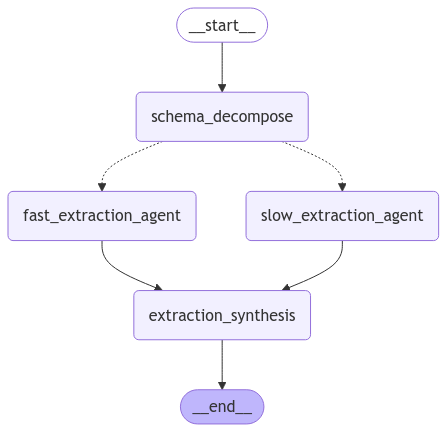

In [54]:
# Build the graph
graph_builder = StateGraph(State)
graph_builder.add_node("schema_decompose", schema_decompose)
graph_builder.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder.add_node("slow_extraction_agent", slow_extraction_agent)
graph_builder.add_node("extraction_synthesis", extraction_synthesis)
graph_builder.add_edge(START, "schema_decompose")
graph_builder.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent": "slow_extraction_agent",
    },
)
graph_builder.add_edge(
    ["fast_extraction_agent", "slow_extraction_agent"], "extraction_synthesis"
)
graph_builder.add_edge("extraction_synthesis", END)
# Compile the graph
graph = graph_builder.compile()

viz_graph(graph)

### Fast & Slow Route with DPE (Deep Extraction)
Validation loop.

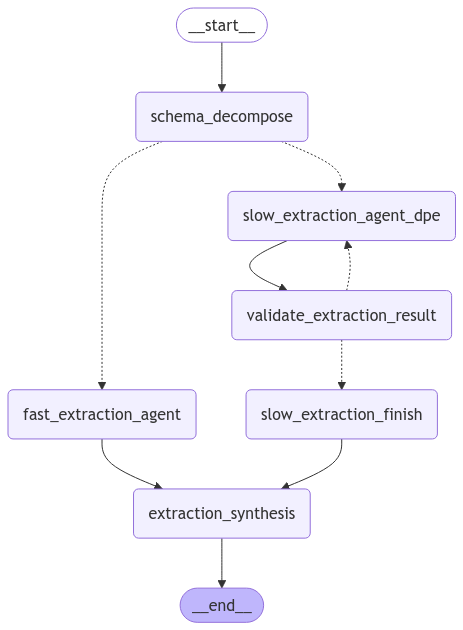

In [55]:
# Build the graph
graph_builder_dpe = StateGraph(State)
graph_builder_dpe.add_node("schema_decompose", schema_decompose)
graph_builder_dpe.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder_dpe.add_node("slow_extraction_agent_dpe", slow_extraction_agent_dpe)
graph_builder_dpe.add_node("validate_extraction_result", validate_extraction_result)
graph_builder_dpe.add_node("slow_extraction_finish", slow_extraction_finish)
graph_builder_dpe.add_node("extraction_synthesis", extraction_synthesis)
graph_builder_dpe.add_edge(START, "schema_decompose")
graph_builder_dpe.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent_dpe": "slow_extraction_agent_dpe",
    },
)
graph_builder_dpe.add_edge("slow_extraction_agent_dpe", "validate_extraction_result")
graph_builder_dpe.add_conditional_edges(
    "validate_extraction_result",
    validate_extraction_result_route,
    {
        "slow_extraction_agent_dpe": "slow_extraction_agent_dpe",
        "slow_extraction_finish": "slow_extraction_finish",
    },
)
graph_builder_dpe.add_edge(
    ["fast_extraction_agent", "slow_extraction_finish"], "extraction_synthesis"
)
graph_builder_dpe.add_edge("extraction_synthesis", END)
# Compile the graph
graph_dpe = graph_builder_dpe.compile()

viz_graph(graph_dpe)

## Run the Graphs
### Vanilla F&S

Batch extraction for both simple and complex entities.

In [12]:
import sys

logger.remove()
logger.add(sys.stderr, level="INFO")

for s in graph.stream(
    {
        "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
        "json_schema": schema,
        "method": "F&S",
    },
):
    print(s)

2025-02-23 17:11:58.433 | INFO     | __main__:fast_extraction_agent:91 - Batch extracting simple entities from the 43-101 report
2025-02-23 17:11:58.434 | INFO     | __main__:slow_extraction_agent:103 - Batch extracting complex entities from the 43-101 report
2025-02-23 17:11:58.434 | INFO     | __main__:batch_extract:11 - Retrieving OpenAI assistant
2025-02-23 17:11:58.435 | INFO     | __main__:batch_extract:11 - Retrieving OpenAI assistant


{'schema_decompose': {'simple_entities': ['mineral_site_name', 'state_or_province', 'country', 'top_1_deposit_type', 'top_1_deposit_environment'], 'complex_entities': ['total_grade', 'total_tonnage']}}


2025-02-23 17:11:59.254 | INFO     | __main__:batch_extract:14 - Retrieving the OpenAI file ID
2025-02-23 17:11:59.580 | INFO     | __main__:batch_extract:14 - Retrieving the OpenAI file ID
2025-02-23 17:11:59.728 | INFO     | __main__:batch_extract:20 - Creating the messages
2025-02-23 17:11:59.729 | INFO     | __main__:batch_extract:38 - Prompting the OpenAI assistant
2025-02-23 17:11:59.963 | INFO     | __main__:batch_extract:20 - Creating the messages
2025-02-23 17:11:59.964 | INFO     | __main__:batch_extract:38 - Prompting the OpenAI assistant


{'fast_extraction_agent': {'fast_extraction_agent_result': {'mineral_site_name': 'Kun-Manie Nickel Project', 'state_or_province': 'Not Found', 'country': 'Russia', 'top_1_deposit_type': 'Nickel', 'top_1_deposit_environment': 'Open pit mining'}}}
{'slow_extraction_agent': {'slow_extraction_agent_result': {'total_grade': 0.48, 'total_tonnage': 53.3}}}
{'extraction_synthesis': {'final_extraction_result': {'mineral_site_name': 'Kun-Manie Nickel Project', 'state_or_province': 'Not Found', 'country': 'Russia', 'top_1_deposit_type': 'Nickel', 'top_1_deposit_environment': 'Open pit mining', 'total_grade': 0.48, 'total_tonnage': 53.3}}}


### F&S with DPE

In [13]:
# Call the graph: here we call it to generate a list of jokes
for s in graph_dpe.stream(
    {
        "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
        "json_schema": schema,
        "method": "DPE",
        "fast_extraction_agent_result": {},
        "slow_extraction_agent_result": {},
    },
    {"recursion_limit": 12},
):
    print(s)

2025-02-23 17:12:38.451 | INFO     | __main__:fast_extraction_agent:91 - Batch extracting simple entities from the 43-101 report
2025-02-23 17:12:38.452 | INFO     | __main__:batch_extract:11 - Retrieving OpenAI assistant
2025-02-23 17:12:38.452 | INFO     | __main__:slow_extraction_agent_dpe:118 - Deep extraction of complex entities from the 43-101 report
2025-02-23 17:12:38.454 | INFO     | __main__:slow_extraction_agent_dpe:129 - Extracting entities from the 43-101 report
2025-02-23 17:12:38.455 | INFO     | __main__:deep_extract:48 - Extracting total_grade from data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf


{'schema_decompose': {'simple_entities': ['mineral_site_name', 'state_or_province', 'country', 'top_1_deposit_type', 'top_1_deposit_environment'], 'complex_entities': ['total_grade', 'total_tonnage']}}


2025-02-23 17:12:38.686 | INFO     | __main__:batch_extract:14 - Retrieving the OpenAI file ID
2025-02-23 17:12:39.088 | INFO     | __main__:batch_extract:20 - Creating the messages
2025-02-23 17:12:39.089 | INFO     | __main__:batch_extract:38 - Prompting the OpenAI assistant
2025-02-23 17:12:47.037 | INFO     | __main__:deep_extract:48 - Extracting total_tonnage from data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf


{'fast_extraction_agent': {'fast_extraction_agent_result': {'mineral_site_name': 'Kun-Manie Nickel Project', 'state_or_province': 'Amur', 'country': 'Russia', 'top_1_deposit_type': 'Nickel', 'top_1_deposit_environment': 'Flat-lying, shallow-dipping sills'}}}


2025-02-23 17:12:55.971 | INFO     | __main__:validate_extraction_result:185 - Validating slow extraction result


{'slow_extraction_agent_dpe': {'slow_extraction_agent_result': {'total_grade': 0.48, 'total_tonnage': 53.3}, 'messages': [{'role': 'assistant', 'content': '<thinking>\nTo find the total grade of nickel deposits from the 43-101 report, I need to look for the section where the mineral resource estimates are summarized. This typically includes the grades for different minerals, including nickel. The search results provided a table summarizing the SRK Independent Mineral Resource Estimate, which includes the nickel grades for various orebodies in percentage format. I will extract the relevant nickel grades from this table to determine the total grade.\n</thinking>\n\n<output>0.48</output>'}, {'role': 'assistant', 'content': '<thinking>\n\nThe search results provide detailed information about the mineral resource estimates for the Kun-Manie project, including tonnage data for different orebodies. The total tonnage is given as a grand total in the summary table. \n\nFrom the search results, 

In [14]:
import sys

from langgraph.errors import GraphRecursionError

logger.remove()
logger.add(sys.stderr, level="DEBUG")

try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
            "json_schema": schema,
            "method": "DPE",
            "fast_extraction_agent_result": {},
            "slow_extraction_agent_result": {},
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

2025-02-23 17:13:01.898 | DEBUG    | __main__:schema_decompose:67 - Response: <thinking>
"mineral_site_name", "state_or_province", "country", "top_1_deposit_type", and "top_1_deposit_environment" are not complex entities and can be extracted directly from the text. However, "total_grade" and "total_tonnage" are complex entities because they require summing or calculating values based on individual nickel deposits, which involves additional reasoning and context.
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "state_or_province", "country", "top_1_deposit_type", "top_1_deposit_environment"]
2. Complex entities: ["total_grade", "total_tonnage"]
</output>
2025-02-23 17:13:01.899 | DEBUG    | __main__:schema_decompose:68 - Simple entities: ['mineral_site_name', 'state_or_province', 'country', 'top_1_deposit_type', 'top_1_deposit_environment']
2025-02-23 17:13:01.900 | DEBUG    | __main__:schema_decompose:69 - Complex entities: ['total_grade', 'total_tonnage']
2025-02-23 17:

In [15]:
print(json.dumps(result["final_extraction_result"], indent=4))

{
    "mineral_site_name": "Kun-Manie Nickel Project",
    "state_or_province": "Not Found",
    "country": "Russia",
    "top_1_deposit_type": "Nickel",
    "top_1_deposit_environment": "Open pit mining",
    "total_grade": 0.48,
    "total_tonnage": 53.3
}


In [16]:
try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/02c1ca57538c379d05d9f65f1cbd8570786c2398e24dcc600abf92e617207046a2.pdf",
            "json_schema": schema,
            "method": "DPE",
            "fast_extraction_agent_result": {},
            "slow_extraction_agent_result": {},
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

2025-02-23 17:13:42.335 | DEBUG    | __main__:schema_decompose:67 - Response: <thinking>
"mineral_site_name", "state_or_province", "country", "top_1_deposit_type", and "top_1_deposit_environment" are all simple entities that can be extracted directly from the text. However, "total_grade" and "total_tonnage" are complex entities because they require additional calculations or aggregations of the nickel deposits to determine their respective values. 
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "state_or_province", "country", "top_1_deposit_type", "top_1_deposit_environment"]
2. Complex entities: ["total_grade", "total_tonnage"]
</output>
2025-02-23 17:13:42.336 | DEBUG    | __main__:schema_decompose:68 - Simple entities: ['mineral_site_name', 'state_or_province', 'country', 'top_1_deposit_type', 'top_1_deposit_environment']
2025-02-23 17:13:42.336 | DEBUG    | __main__:schema_decompose:69 - Complex entities: ['total_grade', 'total_tonnage']
2025-02-23 17:13:42.338 | IN

In [17]:
print(json.dumps(result["final_extraction_result"], indent=4))

{
    "mineral_site_name": "Kun-Manie",
    "state_or_province": "Amur Oblast",
    "country": "Russia",
    "top_1_deposit_type": "nickel sulphide",
    "top_1_deposit_environment": "open pit mining",
    "total_grade": 0.55,
    "total_tonnage": 38.2
}


In [56]:
try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/021a794659a5c972b322e3bda39a1740793bb55223899eca13766ca7e84abdfded.pdf",
            "json_schema": schema,
            "method": "DPE",
            "fast_extraction_agent_result": {},
            "slow_extraction_agent_result": {},
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")
print(json.dumps(result["final_extraction_result"], indent=4))

2025-02-23 17:27:09.655 | DEBUG    | __main__:schema_decompose:67 - Response: <thinking>
The entities "mineral_site_name", "country", and "state_or_province" are not complex entities and can be extracted directly from the text. However, "total_grade" and "total_tonnage" are complex entities because they can be either numbers or strings and require additional context to determine their values accurately. Additionally, "top_1_deposit_type" and "top_1_deposit_environment" are also complex entities because they require specific knowledge about the mineral site to determine the most likely deposit type and environment.
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "country", "state_or_province"]
2. Complex entities: ["total_grade", "total_tonnage", "top_1_deposit_type", "top_1_deposit_environment"]
</output>
2025-02-23 17:27:09.656 | DEBUG    | __main__:schema_decompose:68 - Simple entities: ['mineral_site_name', 'country', 'state_or_province']
2025-02-23 17:27:09.656 | DEB

{
    "mineral_site_name": "Wolf Mountain Property",
    "country": "Canada",
    "state_or_province": "Ontario",
    "total_grade": "Not Found",
    "total_tonnage": "Not Found",
    "top_1_deposit_type": "Noril'sk-type",
    "top_1_deposit_environment": "Not Found"
}
